# AI012 Anomaly Model Comparison

Loads saved AI012 anomaly optimization result files for Isolation Forest, LOF, One-Class SVM, and PyTorch Autoencoder across unsupervised and supervised-threshold evaluation modes, then generates comparison tables, rankings, stability comparison, and recommendations.

## Evaluation Modes

Each base anomaly detector is compared twice. The unsupervised run uses score-quantile thresholding from the configured contamination target. The supervised run uses Role C labels on the validation split to choose the threshold that maximizes F1, then reports supervised metrics on the held-out test split.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

sns.set_theme(style="whitegrid")


def find_ai012_root(start=None):
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if path.name == "ai012-anomaly":
            return path
        candidate = path / "ai-ml" / "models" / "ai012-anomaly"
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate ai-ml/models/ai012-anomaly")


AI012_ROOT = find_ai012_root()
COMPARISON_ROOT = AI012_ROOT / "comparison"
REPORTS_DIR = COMPARISON_ROOT / "reports"
GRAPHS_DIR = COMPARISON_ROOT / "graphs"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)
AI012_ROOT

WindowsPath('C:/Users/koolg/OneDrive - Deakin University/PHOENIX/Phoenix Github Repo/ai-ml/models/ai012-anomaly')

In [2]:
MODEL_CONFIGS = {
    "isolation_forest": AI012_ROOT / "configs" / "isolation_forest_config.yaml",
    "lof": AI012_ROOT / "lof" / "configs" / "lof_config.yaml",
    "one_class_svm": AI012_ROOT / "one_class_svm" / "configs" / "one_class_svm_config.yaml",
    "autoencoder": AI012_ROOT / "autoencoder" / "configs" / "autoencoder_config.yaml",
}
EVALUATION_MODES = ["unsupervised", "supervised"]


def load_yaml(path):
    with path.open("r", encoding="utf-8") as handle:
        return yaml.safe_load(handle)


def resolve_from_config(config_path, value):
    if not value:
        return None
    path = Path(value)
    if path.is_absolute():
        return path
    return (config_path.parent / path).resolve()


def mode_path(base_path, model_name, mode, suffix):
    if mode == "unsupervised":
        return base_path
    return base_path.with_name(f"{model_name}_supervised_{suffix}")


model_rows = []
threshold_frames = []

for model_name, config_path in MODEL_CONFIGS.items():
    config = load_yaml(config_path)
    outputs = config.get("outputs", {})
    base_metrics_path = resolve_from_config(config_path, outputs.get("results_file"))
    base_threshold_path = resolve_from_config(config_path, outputs.get("threshold_file"))
    config_label = str(config_path.relative_to(AI012_ROOT))

    for mode in EVALUATION_MODES:
        metrics_path = mode_path(base_metrics_path, model_name, mode, "metrics.json")
        threshold_path = mode_path(base_threshold_path, model_name, mode, "threshold_tuning.csv")
        row = {
            "model_run": f"{model_name}_{mode}",
            "base_model": model_name,
            "evaluation_mode": mode,
            "config_path": config_label,
            "metrics_path": str(metrics_path.relative_to(AI012_ROOT)) if metrics_path else None,
            "metrics_exists": bool(metrics_path and metrics_path.exists()),
            "threshold_path": str(threshold_path.relative_to(AI012_ROOT)) if threshold_path else None,
            "threshold_exists": bool(threshold_path and threshold_path.exists()),
            "configured_train_split": config.get("dataset", {}).get("train_split"),
            "configured_val_split": config.get("dataset", {}).get("val_split"),
            "configured_test_split": config.get("dataset", {}).get("test_split"),
            "configured_contamination": config.get("evaluation", {}).get("default_contamination"),
            "configured_epochs": config.get("training", {}).get("epochs"),
        }

        if metrics_path and metrics_path.exists():
            with metrics_path.open("r", encoding="utf-8") as handle:
                metrics = json.load(handle)
            row.update(metrics)
            row["base_model"] = metrics.get("model", model_name)
            row["evaluation_mode"] = metrics.get("evaluation_mode", mode)
            row["model_run"] = f"{row['base_model']}_{row['evaluation_mode']}"

        model_rows.append(row)

        if threshold_path and threshold_path.exists():
            threshold_df = pd.read_csv(threshold_path)
            threshold_df.insert(0, "base_model", model_name)
            threshold_df.insert(1, "evaluation_mode", mode)
            threshold_df.insert(2, "model_run", f"{model_name}_{mode}")
            threshold_frames.append(threshold_df)

comparison_df = pd.DataFrame(model_rows)
threshold_df = pd.concat(threshold_frames, ignore_index=True) if threshold_frames else pd.DataFrame()

comparison_df.to_csv(REPORTS_DIR / "model_comparison_table.csv", index=False)
if not threshold_df.empty:
    threshold_df.to_csv(REPORTS_DIR / "model_threshold_table.csv", index=False)

comparison_df


,model_run,base_model,evaluation_mode,config_path,metrics_path,metrics_exists,threshold_path,threshold_exists,configured_train_split,configured_val_split,...,false_negative_rate,supervision_type,label_source,test_rows,label_anomaly_rate,true_negative,false_positive,false_negative,true_positive,best_val_loss
0,isolation_forest_unsupervised,isolation_forest,unsupervised,configs\isolation_forest_config.yaml,reports\isolation_forest_metrics.json,True,reports\isolation_forest_threshold_tuning.csv,True,0.7,0.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,isolation_forest_supervised,isolation_forest,supervised,configs\isolation_forest_config.yaml,reports\isolation_forest_supervised_metrics.json,True,reports\isolation_forest_supervised_threshold_...,True,0.7,0.15,...,0.544937,role_c_threshold_selection,data\processed\anomaly_labels_v1.csv,25431.0,0.069128,22967.0,706.0,958.0,800.0,NaN
2,lof_unsupervised,lof,unsupervised,lof\configs\lof_config.yaml,lof\reports\lof_metrics.json,True,lof\reports\lof_threshold_tuning.csv,True,0.7,0.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,lof_supervised,lof,supervised,lof\configs\lof_config.yaml,lof\reports\lof_supervised_metrics.json,True,lof\reports\lof_supervised_threshold_tuning.csv,True,0.7,0.15,...,0.493743,role_c_threshold_selection,data\processed\anomaly_labels_v1.csv,25431.0,0.069128,17780.0,5893.0,868.0,890.0,NaN
4,one_class_svm_unsupervised,one_class_svm,unsupervised,one_class_svm\configs\one_class_svm_config.yaml,one_class_svm\reports\one_class_svm_metrics.json,True,one_class_svm\reports\one_class_svm_threshold_...,True,0.7,0.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,one_class_svm_supervised,one_class_svm,supervised,one_class_svm\configs\one_class_svm_config.yaml,one_class_svm\reports\one_class_svm_supervised...,True,one_class_svm\reports\one_class_svm_supervised...,True,0.7,0.15,...,0.615472,role_c_threshold_selection,data\processed\anomaly_labels_v1.csv,25431.0,0.069128,23243.0,430.0,1082.0,676.0,NaN
6,autoencoder_unsupervised,autoencoder,unsupervised,autoencoder\configs\autoencoder_config.yaml,autoencoder\reports\autoencoder_metrics.json,True,autoencoder\reports\autoencoder_threshold_tuni...,True,0.7,0.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.112916
7,autoencoder_supervised,autoencoder,supervised,autoencoder\configs\autoencoder_config.yaml,autoencoder\reports\autoencoder_supervised_met...,True,autoencoder\reports\autoencoder_supervised_thr...,True,0.7,0.15,...,0.448805,role_c_threshold_selection,data\processed\anomaly_labels_v1.csv,25431.0,0.069128,22861.0,812.0,789.0,969.0,0.112916


## Best Threshold Table

In [3]:
best_threshold_columns = [
    "model_run",
    "base_model",
    "evaluation_mode",
    "n_rows",
    "n_features",
    "test_rows",
    "label_anomaly_rate",
    "configured_train_split",
    "configured_val_split",
    "configured_test_split",
    "configured_contamination",
    "configured_epochs",
    "training_epochs",
    "best_epoch",
    "threshold",
    "threshold_quantile",
    "anomaly_rate",
    "stability_score",
]
best_threshold_df = comparison_df[[col for col in best_threshold_columns if col in comparison_df.columns]].copy()
best_threshold_df.to_csv(REPORTS_DIR / "best_threshold_table.csv", index=False)
best_threshold_df


,model_run,base_model,evaluation_mode,n_rows,n_features,test_rows,label_anomaly_rate,configured_train_split,configured_val_split,configured_test_split,configured_contamination,configured_epochs,training_epochs,best_epoch,threshold,threshold_quantile,anomaly_rate,stability_score
0,isolation_forest_unsupervised,isolation_forest,unsupervised,169539,50,NaN,NaN,0.7,0.15,0.15,0.07,1.0,1.0,1.0,-0.000030,0.93000,0.070229,1.0
1,isolation_forest_supervised,isolation_forest,supervised,169539,50,25431.0,0.069128,0.7,0.15,0.15,0.07,1.0,1.0,NaN,0.005870,0.94055,0.059219,1.0
2,lof_unsupervised,lof,unsupervised,169539,50,NaN,NaN,0.7,0.15,0.15,0.07,NaN,NaN,NaN,0.006246,0.93000,0.071566,1.0
3,lof_supervised,lof,supervised,169539,50,25431.0,0.069128,0.7,0.15,0.15,0.07,NaN,NaN,NaN,-0.137485,0.73760,0.266722,1.0
4,one_class_svm_unsupervised,one_class_svm,unsupervised,169539,50,NaN,NaN,0.7,0.15,0.15,0.07,NaN,NaN,NaN,1.975378,0.93000,0.070111,1.0
5,one_class_svm_supervised,one_class_svm,supervised,169539,50,25431.0,0.069128,0.7,0.15,0.15,0.07,NaN,NaN,NaN,75.246536,0.95540,0.043490,1.0
6,autoencoder_unsupervised,autoencoder,unsupervised,169539,50,NaN,NaN,0.7,0.15,0.15,0.07,50.0,NaN,14.0,0.154011,0.93000,0.070780,1.0
7,autoencoder_supervised,autoencoder,supervised,169539,50,25431.0,0.069128,0.7,0.15,0.15,0.07,50.0,50.0,14.0,0.154647,0.93065,0.070033,1.0


## Supervised Rankings

In [4]:
def supervised_ranking(metric, ascending=False):
    supervised = comparison_df[comparison_df["evaluation_mode"] == "supervised"].copy()
    if metric not in supervised.columns or supervised[metric].dropna().empty:
        return pd.DataFrame({"message": [f"{metric} is unavailable for supervised runs."]})
    return supervised[["model_run", "base_model", metric]].dropna().sort_values(metric, ascending=ascending).reset_index(drop=True)


ranking_f1 = supervised_ranking("f1", ascending=False)
ranking_pr_auc = supervised_ranking("pr_auc", ascending=False)
ranking_false_positive_rate = supervised_ranking("false_positive_rate", ascending=True)

ranking_f1.to_csv(REPORTS_DIR / "ranking_by_f1.csv", index=False)
ranking_pr_auc.to_csv(REPORTS_DIR / "ranking_by_pr_auc.csv", index=False)
ranking_false_positive_rate.to_csv(REPORTS_DIR / "ranking_by_false_positive_rate.csv", index=False)

display(ranking_f1)
display(ranking_pr_auc)
display(ranking_false_positive_rate)


,model_run,base_model,f1
0,autoencoder_supervised,autoencoder,0.547612
1,isolation_forest_supervised,isolation_forest,0.490196
2,one_class_svm_supervised,one_class_svm,0.472067
3,lof_supervised,lof,0.208407


,model_run,base_model,pr_auc
0,autoencoder_supervised,autoencoder,0.546037
1,isolation_forest_supervised,isolation_forest,0.531019
2,one_class_svm_supervised,one_class_svm,0.402175
3,lof_supervised,lof,0.123178


,model_run,base_model,false_positive_rate
0,one_class_svm_supervised,one_class_svm,0.018164
1,isolation_forest_supervised,isolation_forest,0.029823
2,autoencoder_supervised,autoencoder,0.034301
3,lof_supervised,lof,0.248933


## Unsupervised Rankings

In [5]:
unsupervised_cols = [
    "model_run",
    "base_model",
    "evaluation_mode",
    "n_rows",
    "n_features",
    "configured_contamination",
    "configured_epochs",
    "training_epochs",
    "best_epoch",
    "anomaly_rate",
    "score_mean",
    "score_std",
    "score_iqr",
    "stability_score",
]
available_unsupervised_cols = [col for col in unsupervised_cols if col in comparison_df.columns]
unsupervised_df = comparison_df[comparison_df["evaluation_mode"] == "unsupervised"][available_unsupervised_cols].copy()

if "stability_score" in unsupervised_df.columns:
    stability_ranking = unsupervised_df.sort_values("stability_score", ascending=False).reset_index(drop=True)
else:
    stability_ranking = pd.DataFrame()

stability_ranking.to_csv(REPORTS_DIR / "stability_comparison.csv", index=False)
stability_ranking


,model_run,base_model,evaluation_mode,n_rows,n_features,configured_contamination,configured_epochs,training_epochs,best_epoch,anomaly_rate,score_mean,score_std,score_iqr,stability_score
0,isolation_forest_unsupervised,isolation_forest,unsupervised,169539,50,0.07,1.0,1.0,1.0,0.070229,-0.057296,0.040246,0.042206,1.0
1,lof_unsupervised,lof,unsupervised,169539,50,0.07,NaN,NaN,NaN,0.071566,-0.158394,0.120474,0.097281,1.0
2,one_class_svm_unsupervised,one_class_svm,unsupervised,169539,50,0.07,NaN,NaN,NaN,0.070111,-149.648839,147.771633,140.341836,1.0
3,autoencoder_unsupervised,autoencoder,unsupervised,169539,50,0.07,50.0,NaN,14.0,0.070780,0.093312,0.327775,0.043425,1.0


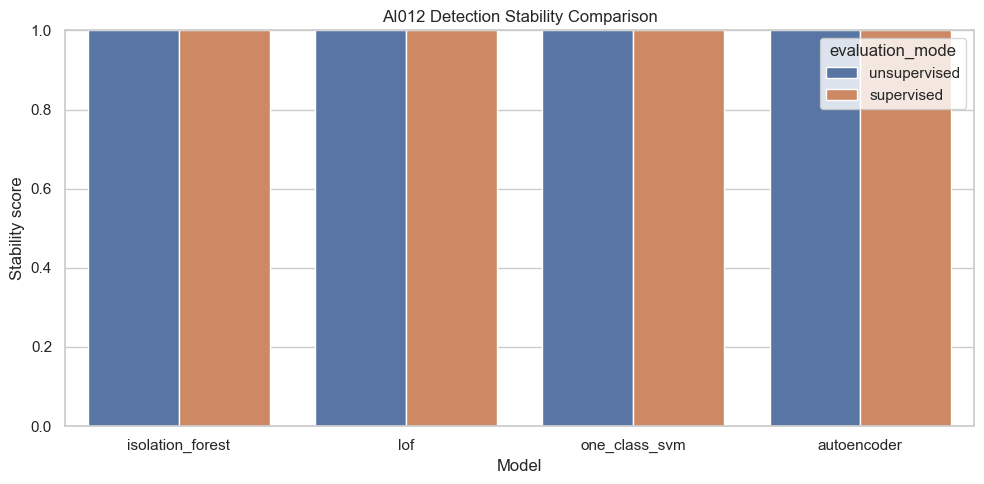

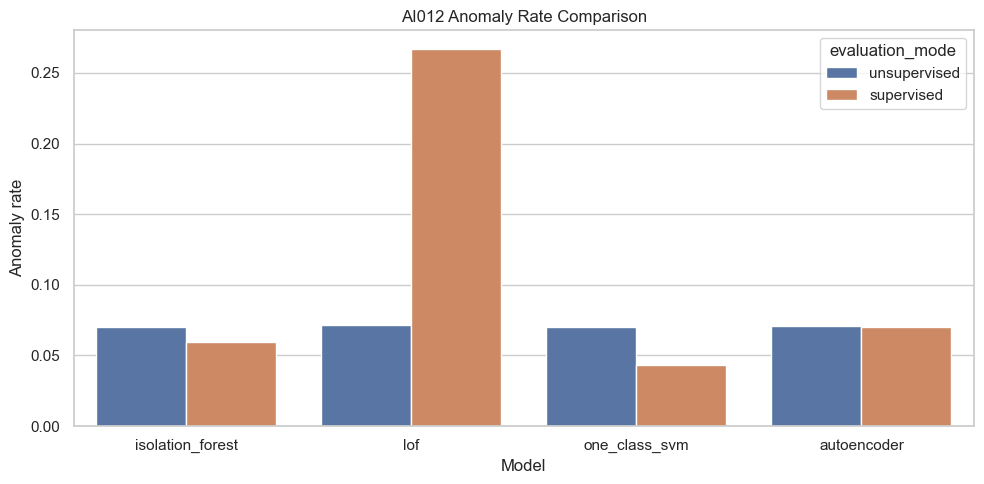

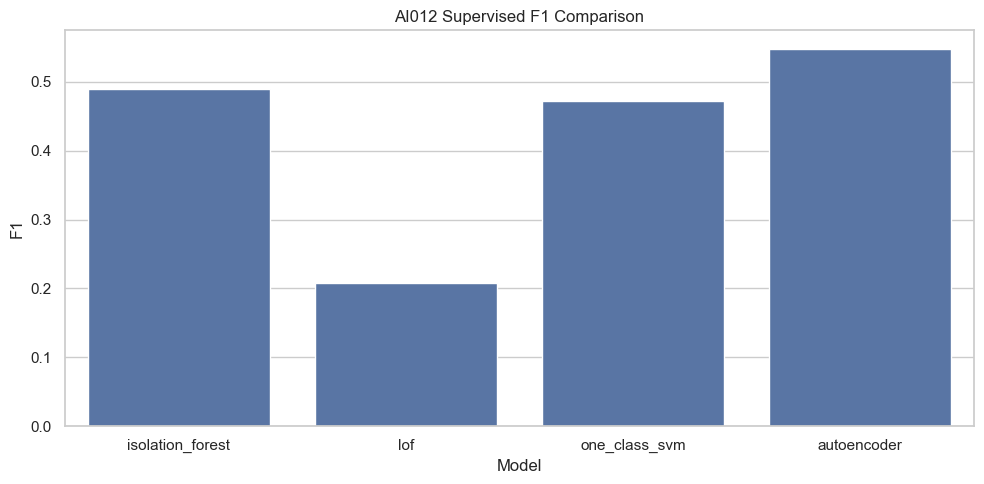

In [6]:
plot_df = comparison_df[comparison_df["metrics_exists"]].copy()
if not plot_df.empty and "stability_score" in plot_df.columns:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x="base_model", y="stability_score", hue="evaluation_mode")
    plt.title("AI012 Detection Stability Comparison")
    plt.xlabel("Model")
    plt.ylabel("Stability score")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / "stability_comparison.png", dpi=150)
    plt.show()

if not plot_df.empty and "anomaly_rate" in plot_df.columns:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x="base_model", y="anomaly_rate", hue="evaluation_mode")
    plt.title("AI012 Anomaly Rate Comparison")
    plt.xlabel("Model")
    plt.ylabel("Anomaly rate")
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / "anomaly_rate_comparison.png", dpi=150)
    plt.show()

supervised_plot_df = plot_df[plot_df["evaluation_mode"] == "supervised"]
if not supervised_plot_df.empty and "f1" in supervised_plot_df.columns:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=supervised_plot_df, x="base_model", y="f1")
    plt.title("AI012 Supervised F1 Comparison")
    plt.xlabel("Model")
    plt.ylabel("F1")
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / "supervised_f1_comparison.png", dpi=150)
    plt.show()


## Final Recommendation

In [7]:
target_rate = 0.07
recommendation_df = comparison_df.copy()
recommendations = []

unsupervised_recommendation_df = recommendation_df[recommendation_df["evaluation_mode"] == "unsupervised"].copy()
if {"anomaly_rate", "stability_score"}.issubset(unsupervised_recommendation_df.columns) and unsupervised_recommendation_df["metrics_exists"].any():
    unsupervised_recommendation_df["anomaly_rate_distance"] = (unsupervised_recommendation_df["anomaly_rate"] - target_rate).abs()
    unsupervised_recommendation_df["recommendation_score"] = unsupervised_recommendation_df["stability_score"] - unsupervised_recommendation_df["anomaly_rate_distance"]
    unsupervised_recommendation_df = unsupervised_recommendation_df.sort_values("recommendation_score", ascending=False).reset_index(drop=True)
    recommendations.append(
        f"Recommended unsupervised candidate: {unsupervised_recommendation_df.loc[0, 'base_model']}. "
        "This ranks unsupervised runs by high detection stability and anomaly-rate alignment with the configured contamination target."
    )
else:
    recommendations.append("No complete unsupervised model metrics were found.")

supervised_recommendation_df = recommendation_df[recommendation_df["evaluation_mode"] == "supervised"].copy()
if "f1" in supervised_recommendation_df.columns and supervised_recommendation_df["f1"].dropna().any():
    supervised_recommendation_df = supervised_recommendation_df.sort_values(["f1", "pr_auc", "recall", "precision"], ascending=False).reset_index(drop=True)
    recommendations.append(
        f"Recommended supervised-threshold candidate: {supervised_recommendation_df.loc[0, 'base_model']}. "
        "This ranks supervised runs by held-out F1, then PR-AUC, recall, and precision."
    )
else:
    recommendations.append("No complete supervised model metrics were found. Run the four model optimization notebooks first, then rerun this comparison notebook.")

recommendation_text = "\n\n".join(recommendations)
with (REPORTS_DIR / "final_recommendation.md").open("w", encoding="utf-8") as handle:
    handle.write("# AI012 Anomaly Model Recommendation\n\n")
    handle.write(recommendation_text + "\n")

print(recommendation_text)
display(unsupervised_recommendation_df if 'unsupervised_recommendation_df' in globals() else pd.DataFrame())
display(supervised_recommendation_df if 'supervised_recommendation_df' in globals() else pd.DataFrame())


Recommended unsupervised candidate: one_class_svm. This ranks unsupervised runs by high detection stability and anomaly-rate alignment with the configured contamination target.

Recommended supervised-threshold candidate: autoencoder. This ranks supervised runs by held-out F1, then PR-AUC, recall, and precision.


,model_run,base_model,evaluation_mode,config_path,metrics_path,metrics_exists,threshold_path,threshold_exists,configured_train_split,configured_val_split,...,label_source,test_rows,label_anomaly_rate,true_negative,false_positive,false_negative,true_positive,best_val_loss,anomaly_rate_distance,recommendation_score
0,one_class_svm_unsupervised,one_class_svm,unsupervised,one_class_svm\configs\one_class_svm_config.yaml,one_class_svm\reports\one_class_svm_metrics.json,True,one_class_svm\reports\one_class_svm_threshold_...,True,0.7,0.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000111,0.999889
1,isolation_forest_unsupervised,isolation_forest,unsupervised,configs\isolation_forest_config.yaml,reports\isolation_forest_metrics.json,True,reports\isolation_forest_threshold_tuning.csv,True,0.7,0.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000229,0.999771
2,autoencoder_unsupervised,autoencoder,unsupervised,autoencoder\configs\autoencoder_config.yaml,autoencoder\reports\autoencoder_metrics.json,True,autoencoder\reports\autoencoder_threshold_tuni...,True,0.7,0.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.112916,0.000780,0.999220
3,lof_unsupervised,lof,unsupervised,lof\configs\lof_config.yaml,lof\reports\lof_metrics.json,True,lof\reports\lof_threshold_tuning.csv,True,0.7,0.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001566,0.998434


,model_run,base_model,evaluation_mode,config_path,metrics_path,metrics_exists,threshold_path,threshold_exists,configured_train_split,configured_val_split,...,false_negative_rate,supervision_type,label_source,test_rows,label_anomaly_rate,true_negative,false_positive,false_negative,true_positive,best_val_loss
0,autoencoder_supervised,autoencoder,supervised,autoencoder\configs\autoencoder_config.yaml,autoencoder\reports\autoencoder_supervised_met...,True,autoencoder\reports\autoencoder_supervised_thr...,True,0.7,0.15,...,0.448805,role_c_threshold_selection,data\processed\anomaly_labels_v1.csv,25431.0,0.069128,22861.0,812.0,789.0,969.0,0.112916
1,isolation_forest_supervised,isolation_forest,supervised,configs\isolation_forest_config.yaml,reports\isolation_forest_supervised_metrics.json,True,reports\isolation_forest_supervised_threshold_...,True,0.7,0.15,...,0.544937,role_c_threshold_selection,data\processed\anomaly_labels_v1.csv,25431.0,0.069128,22967.0,706.0,958.0,800.0,NaN
2,one_class_svm_supervised,one_class_svm,supervised,one_class_svm\configs\one_class_svm_config.yaml,one_class_svm\reports\one_class_svm_supervised...,True,one_class_svm\reports\one_class_svm_supervised...,True,0.7,0.15,...,0.615472,role_c_threshold_selection,data\processed\anomaly_labels_v1.csv,25431.0,0.069128,23243.0,430.0,1082.0,676.0,NaN
3,lof_supervised,lof,supervised,lof\configs\lof_config.yaml,lof\reports\lof_supervised_metrics.json,True,lof\reports\lof_supervised_threshold_tuning.csv,True,0.7,0.15,...,0.493743,role_c_threshold_selection,data\processed\anomaly_labels_v1.csv,25431.0,0.069128,17780.0,5893.0,868.0,890.0,NaN
